# Trabajo práctico 4: Aprendizaje No Supervisado

In [1]:
%load_ext autoreload
%autoreload 2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

import sys 
sys.path.append(os.path.abspath("./src"))
sys.path.append(os.path.abspath("./data"))

import utils as utls 
import pca as pca
import autoencoder as ae
import clustering as clust
from collections import Counter

## 1. Inspección de Datos

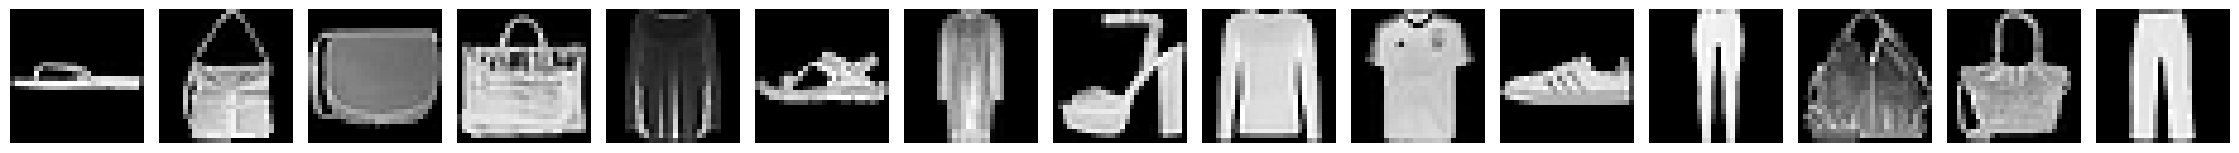

In [2]:
df = pd.read_csv("./data/fashion_mnist_subset.csv")

utls.plot_images(df, 15)
#Ver de hacer las fotos mas grandes


In [3]:
print(df.shape)
print(df.head())

# Separar features y etiquetas
# Asumiendo que la última columna es la etiqueta
X = df.iloc[:, :-1].values  # píxeles
y = df.iloc[:, -1].values   # etiquetas

(25000, 785)
   pixel_0  pixel_1  pixel_2  pixel_3  pixel_4  pixel_5  pixel_6  pixel_7  \
0      0.0      0.0      0.0      0.0      0.0      0.0   0.0039   0.0000   
1      0.0      0.0      0.0      0.0      0.0      0.0   0.0000   0.0000   
2      0.0      0.0      0.0      0.0      0.0      0.0   0.0000   0.0000   
3      0.0      0.0      0.0      0.0      0.0      0.0   0.0000   0.0627   
4      0.0      0.0      0.0      0.0      0.0      0.0   0.0000   0.0000   

   pixel_8  pixel_9  ...  pixel_775  pixel_776  pixel_777  pixel_778  \
0   0.0196   0.0902  ...     0.1647     0.0000     0.0000     0.0000   
1   0.0000   0.0000  ...     0.0000     0.0000     0.0000     0.0000   
2   0.0000   0.0000  ...     0.4235     0.2157     0.0000     0.0000   
3   0.2078   0.0000  ...     0.0549     0.0000     0.1529     0.3843   
4   0.0000   0.0000  ...     0.0000     0.0000     0.0078     0.0000   

   pixel_779  pixel_780  pixel_781  pixel_782  pixel_783  label  
0     0.0000        0.0  

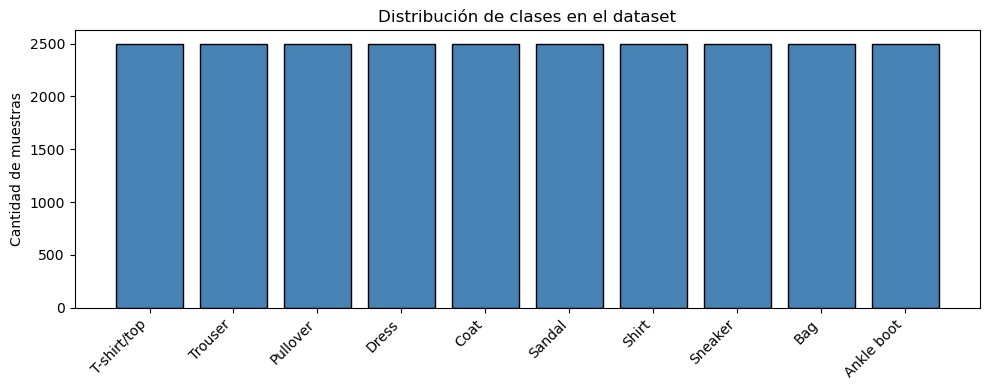

In [4]:
class_names = {
    0: 'T-shirt/top',
    1: 'Trouser',
    2: 'Pullover',
    3: 'Dress',
    4: 'Coat',
    5: 'Sandal',
    6: 'Shirt',
    7: 'Sneaker',
    8: 'Bag',
    9: 'Ankle boot'
}

class_counts = Counter(y)
classes, counts = zip(*sorted(class_counts.items()))
labels = [class_names[c] for c in classes]

utls.barplot(labels, counts)

El dataset esta completamente balanceado, todas las clases tienen 2500 muestras. Esto significa que no hay riesgo de sesgos en el entrenamiento hacia ninguna clase en particular.

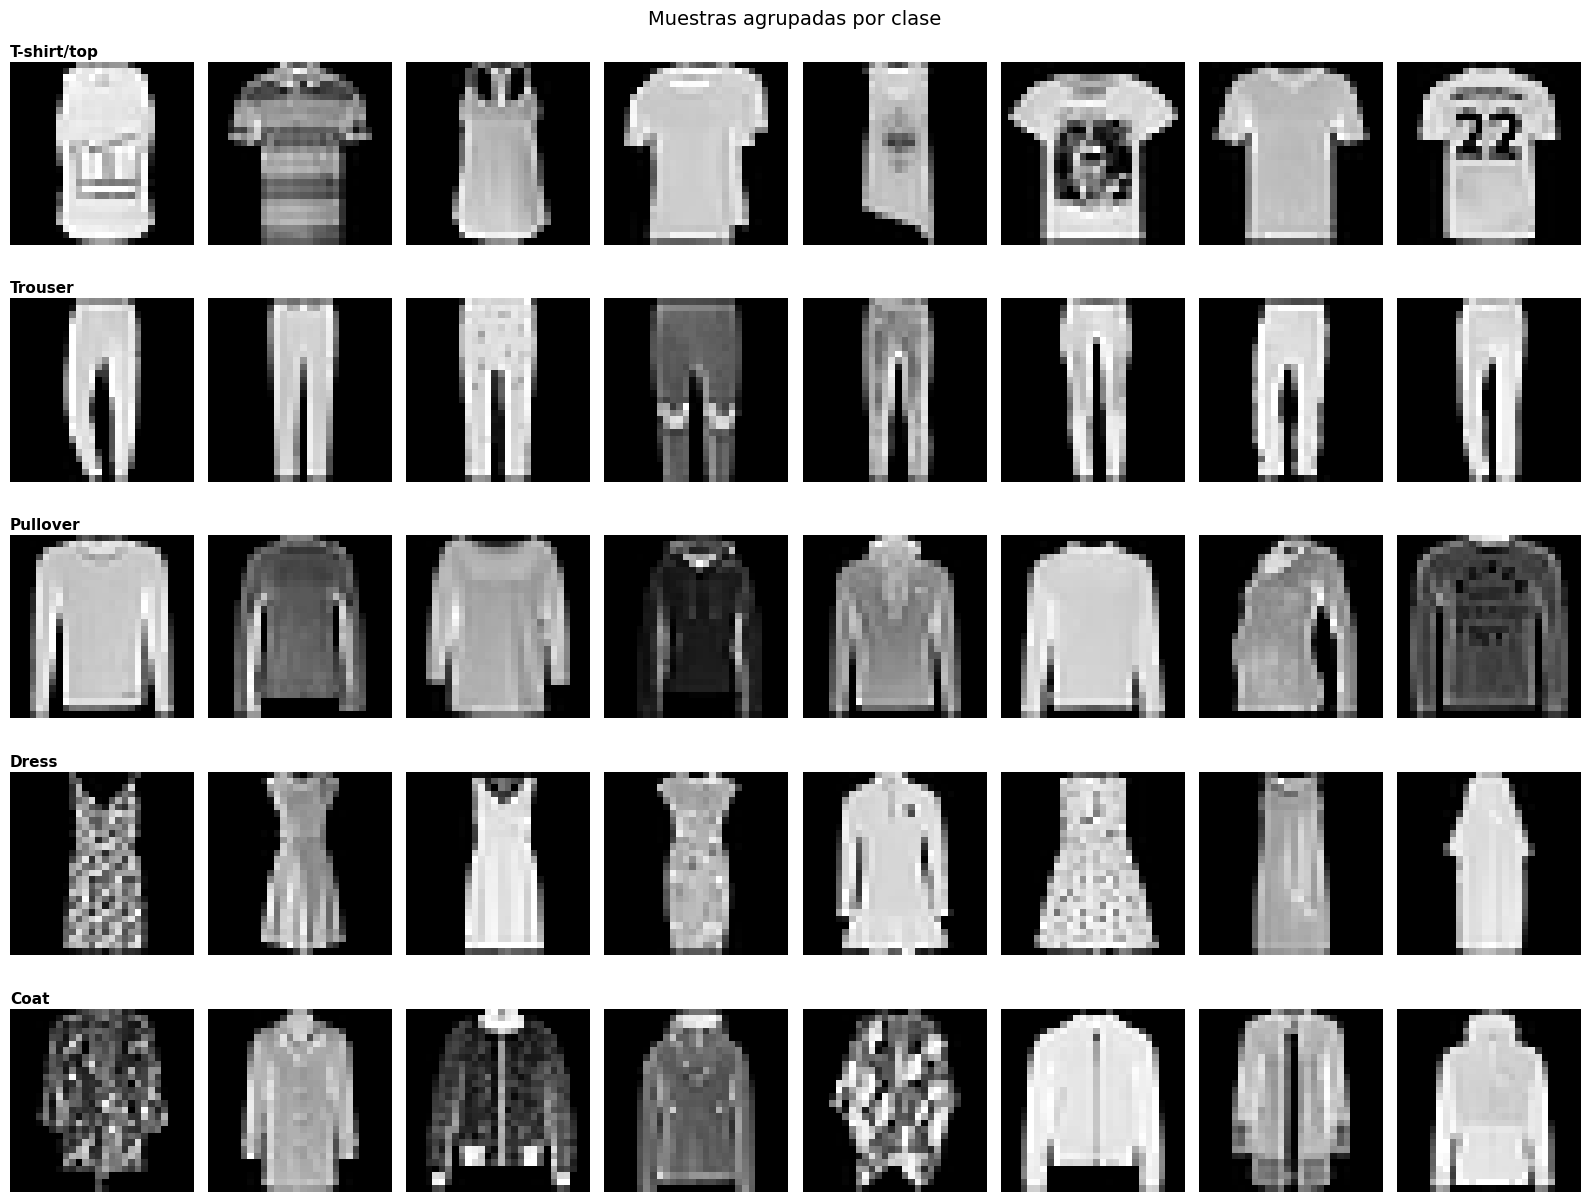

In [5]:
# Llamar la función con 5 clases y 8 muestras por clase
utls.plot_samples_by_class(X, y, class_names, n_samples=8,
                      classes_to_show=[0, 1, 2, 3, 4])

Se puede ver que dentro de las clases propias, la muestras varian mucho entre ellas, ya sea en color, estampado, largo o textura.

Tambien algunas clases pueden confundirse entre si por similitudes en los disenos, como vestidos, tapados y pullovers. Esto significa que los modelos de aprendizaje no supervisado podrian llegar a confundir estas clases.


### Split de Train/Test

In [6]:
# Split estratificado: cada subconjunto debe mantener la misma proporcion de clases que el dataset original

X_train, X_test, y_train, y_test = utls.stratified_split(X, y, test_size=0.2)



## 2. Reduccion de Dimensionalidad

In [7]:
# Estandarizar
X_train_std, X_test_std, med, des = utls.standarization(X_train, X_test)
import psutil
ram = psutil.virtual_memory()
print(f"RAM disponible: {ram.available / 1e9:.1f} GB")
print(f"X_train_std dtype: {X_train_std.dtype}")
print(f"X_train_std shape: {X_train_std.shape}")
print(f"X_train_std size: {X_train_std.nbytes / 1e6:.1f} MB")

RAM disponible: 3.6 GB
X_train_std dtype: float64
X_train_std shape: (20000, 784)
X_train_std size: 125.4 MB


In [8]:
del df, X

X_train_std = X_train_std.astype(np.float32)
X_test_std  = X_test_std.astype(np.float32)

X_train = X_train.astype(np.float32)
X_test  = X_test.astype(np.float32)


In [9]:

# Aprender PCA sobre train para ver varianza
eigenvalues, eigenvectors = pca.pca_fit(X_train_std)

varianza_explicada = eigenvalues / np.sum(eigenvalues)
varianza_acumulada = np.cumsum(varianza_explicada)

# Elegir K componentes que expliquen el 90%
K = np.argmax(varianza_acumulada >= 0.90) + 1
print(f"Componentes para 90% de varianza: {K}")

# Transformar train y test con K componentes
eigenvectors_K = eigenvectors[:, :K]  
X_train_pca = pca.pca_transform(X_train_std, eigenvectors_K)
X_test_pca  = pca.pca_transform(X_test_std,  eigenvectors_K)


Componentes para 90% de varianza: 135


Text(0, 0.5, 'Varianza explicada acumulada')

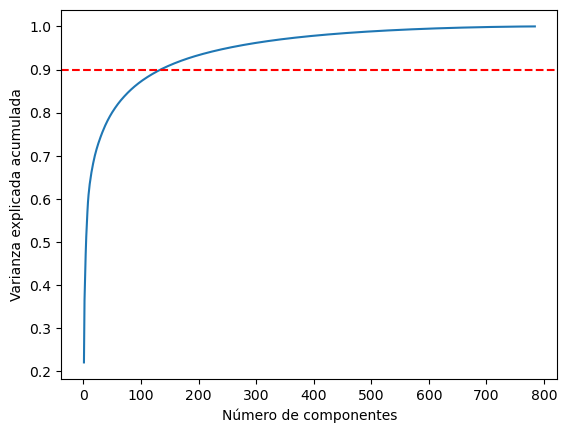

In [10]:
plt.plot(range(1, len(varianza_acumulada)+1), varianza_acumulada)
plt.axhline(y=0.90, color='r', linestyle='--', label='90%')
plt.xlabel('Número de componentes')
plt.ylabel('Varianza explicada acumulada')

Gracias a la reduccion de PCA, se puede identificar que 135 componentes son suficientes para capturar el 90% de la varianza de los datos, y por ende se puede descartar el 10% restante. Esto es porque al realizar la reconstruccion de los datos con estas 135 componentes de mayor varianza, se conserva el 90% de la informacion del dataset. 

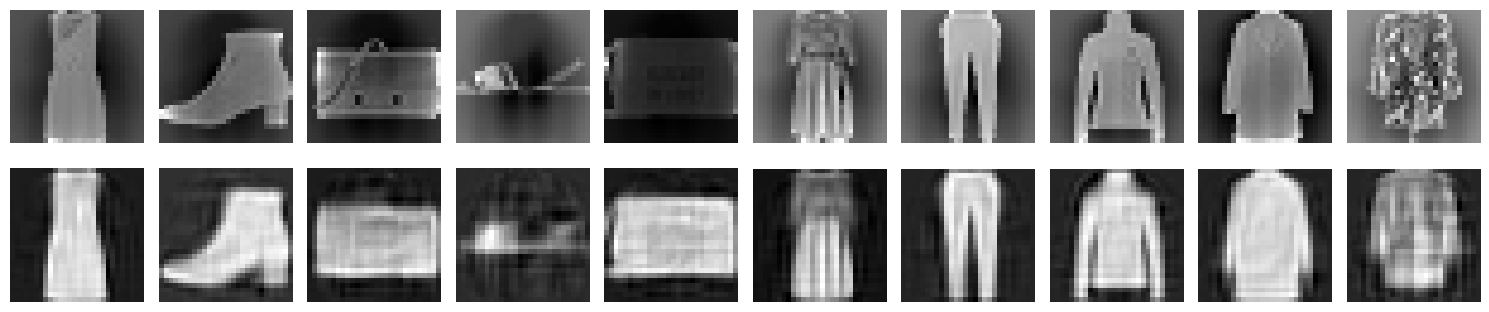

In [11]:

X_reconstruido_std = X_train_pca @ eigenvectors_K.T 
X_reconstruido = X_reconstruido_std * des + med    # des-estandarizar

# 2b - comparación originales vs reconstruidas
utls.plot_images([X_train_std, X_reconstruido], n_images=10,
            titles=["Original", "Reconstruida PCA"])


#### Entrenamiento de AutoEncoder con PyTorch

In [12]:
from torch.utils.data import DataLoader, TensorDataset

# X_train ya estandarizado, shape (N, 784), valores en [0,1]
# Asegurate de que los píxeles estén en [0,1] (dividir por 255 si hace falta)

LATENT_DIM = 135  # igual que PCA
EPOCHS = 50
LR = 1e-3

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Datos como tensores
X_train_t = torch.FloatTensor(X_train_std).to(device)  # usar datos estandarizados o normalizados
X_val_t   = torch.FloatTensor(X_test_std).to(device)

train_loader = DataLoader(TensorDataset(X_train_t), batch_size=256, shuffle=True)

model = ae.Autoencoder(input_dim=784, latent_dim=LATENT_DIM).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
criterion = nn.MSELoss()

train_losses, val_losses = [], []

for epoch in range(EPOCHS):
    model.train()
    batch_loss = []
    for (x_batch,) in train_loader:
        optimizer.zero_grad()
        x_hat = model(x_batch)
        loss = criterion(x_hat, x_batch)
        loss.backward()
        optimizer.step()
        batch_loss.append(loss.item())
    
    # Validación
    model.eval()
    with torch.no_grad():
        val_loss = criterion(model(X_val_t), X_val_t).item()
    
    train_losses.append(sum(batch_loss) / len(batch_loss))
    val_losses.append(val_loss)
    
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{EPOCHS} | Train: {train_losses[-1]:.4f} | Val: {val_losses[-1]:.4f}")

model.eval()
with torch.no_grad():
    X_train_ae = model.encoder(torch.FloatTensor(X_train_std).to(device)).cpu().numpy()
    X_test_ae  = model.encoder(torch.FloatTensor(X_test_std).to(device)).cpu().numpy()

Epoch 10/50 | Train: 0.1670 | Val: 0.1761
Epoch 20/50 | Train: 0.1436 | Val: 0.1462
Epoch 30/50 | Train: 0.1258 | Val: 0.1302
Epoch 40/50 | Train: 0.0996 | Val: 0.1192
Epoch 50/50 | Train: 0.0943 | Val: 0.1129


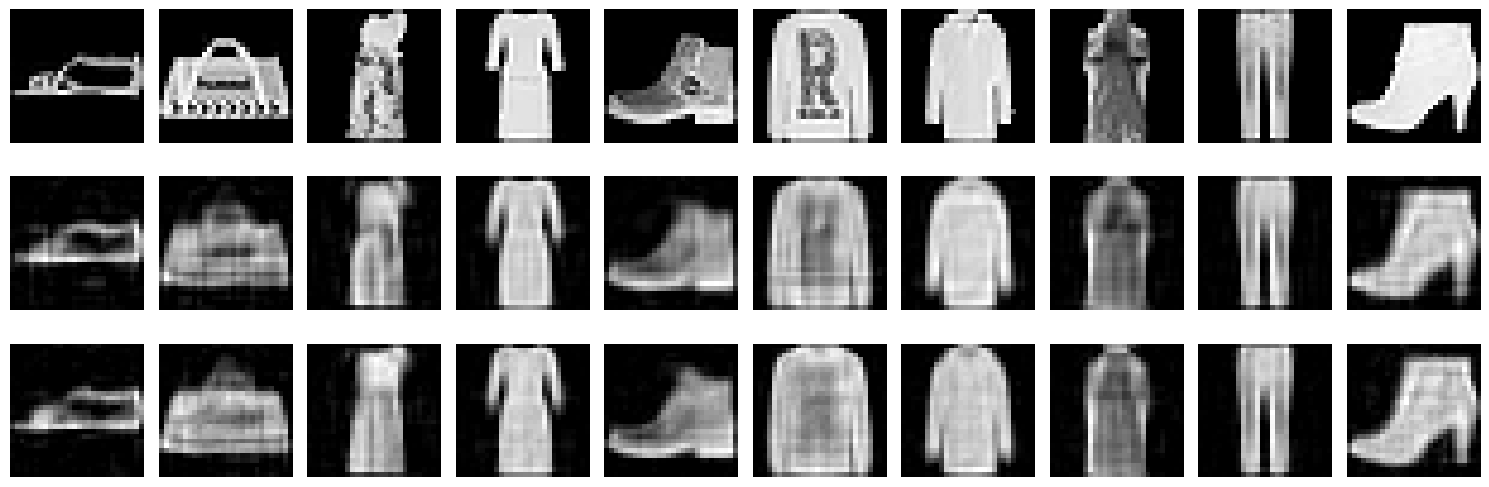

In [13]:
idx = np.random.choice(len(X_test), 10, replace=False)

originales_vis = X_test[idx].astype(np.float32)

# Reconstrucción AE: pasar X_test_std por el modelo completo
model.eval()
with torch.no_grad():
    recon_ae_std = model(torch.FloatTensor(X_test_std[idx]).to(device)).cpu().numpy()
recon_ae = np.clip(recon_ae_std * des + med, 0, 255)

# Reconstrucción PCA
X_test_reconstruido_std = X_test_pca @ eigenvectors_K.T
recon_pca = np.clip(X_test_reconstruido_std[idx] * des + med, 0, 255)

utls.plot_images([originales_vis, recon_pca, recon_ae], n_images=10,
                 titles=["Original", "Reconstruida PCA", "Reconstruida AE"])

## 3. Clustering

Algoritmo K-Means

In [14]:
_, X_cluster, _, y_cluster = utls.stratified_split(X_train_pca, y_train, test_size=3000/len(X_train_pca))

resultados_kmeans = {}
for K in range(5, 16):
    labels, centroids, inertia = clust.kmeans(X_cluster, K)
    resultados_kmeans[K] = {"labels": labels, "centroids": centroids, "inertia": inertia}
    print(f"K={K} | Inertia: {inertia:.2f}")

K=5 | Inertia: 57704.25
K=6 | Inertia: 56460.50
K=7 | Inertia: 54424.82
K=8 | Inertia: 53380.51
K=9 | Inertia: 52971.62
K=10 | Inertia: 51684.97
K=11 | Inertia: 51190.53
K=12 | Inertia: 50597.16
K=13 | Inertia: 50292.34
K=14 | Inertia: 50079.30
K=15 | Inertia: 49442.91


Algortimo GMM

In [18]:
resultados_gmm = {}
for K in range(5, 16):
    labels, mu, sigma, pi, ll = clust.gmm(X_cluster, K, max_iter=100, tol=1e-4, random_seed=42)
    resultados_gmm[K] = {"labels": labels, "mu": mu, "sigma": sigma, "pi": pi, "log_likelihood": ll}
    print(f"K={K} | Log-likelihood: {ll:.2f}")

K=5 | Log-likelihood: -611999.69
K=6 | Log-likelihood: -606932.17
K=7 | Log-likelihood: -604617.53
K=8 | Log-likelihood: -602250.12
K=9 | Log-likelihood: -600861.18
K=10 | Log-likelihood: -597708.85
K=11 | Log-likelihood: -596081.50
K=12 | Log-likelihood: -594793.13
K=13 | Log-likelihood: -593225.90
K=14 | Log-likelihood: -592047.15
K=15 | Log-likelihood: -590199.53


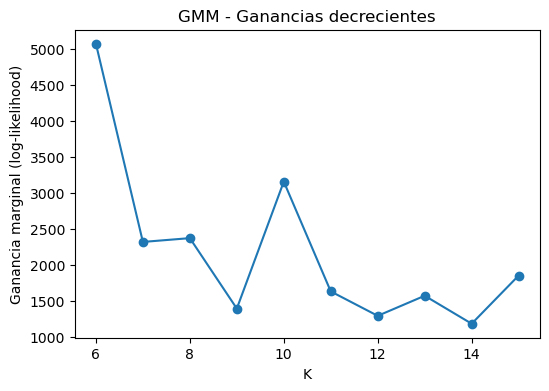

In [19]:
ks = list(resultados_gmm.keys())
lls = [resultados_gmm[k]["log_likelihood"] for k in ks]
ganancia_marginal_gmm = [lls[i] - lls[i-1] for i in range(1, len(lls))]

plt.figure(figsize=(6, 4))
plt.plot(ks[1:], ganancia_marginal_gmm, marker='o')
plt.xlabel("K")
plt.ylabel("Ganancia marginal (log-likelihood)")
plt.title("GMM - Ganancias decrecientes")
plt.show()